## MNIST: recognize digits


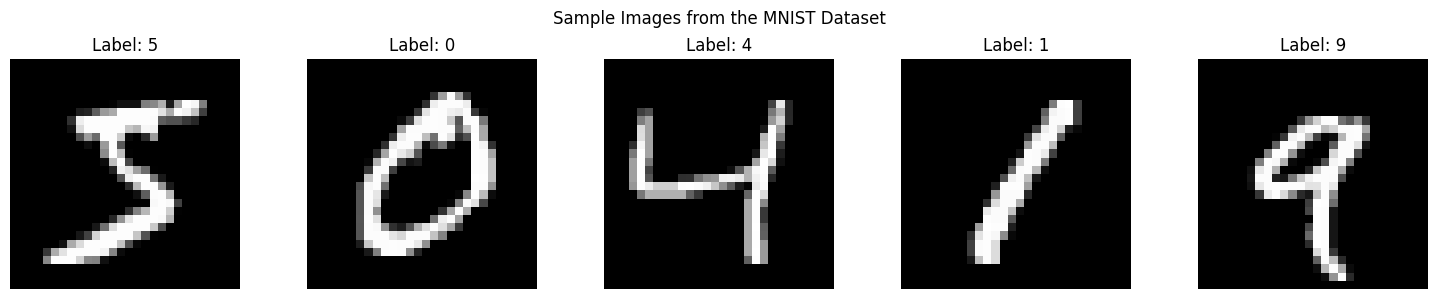

In [18]:
import enum
import ssl

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torchvision 

# Define transformations for the dataset
# totensor converts the PIL image to a PyTorch tensor and
#  Normalize standardizes the pixel values to have a mean of 0.5 and a standard deviation of 0.5, which helps in training the neural network effectively.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))    
])
def load_mnist(train):
    try:
        return torchvision.datasets.MNIST(root='./data', train=train, download=True, transform=transform)
    except RuntimeError as error:
        if 'CERTIFICATE_VERIFY_FAILED' not in str(error):
            raise
        print('MNIST download hit a local SSL certificate issue. Retrying download...')
        ssl._create_default_https_context = ssl._create_unverified_context
        return torchvision.datasets.MNIST(root='./data', train=train, download=True, transform=transform)

# download the MNIST dataset and apply the transformations defined above. 
# The dataset is split into a training set (train=True) and a test set (train=False). 
# The data will be stored in the './data' directory, and if it is not already present, it will be downloaded automatically.
train_set = load_mnist(train=True)
test_set = load_mnist(train=False)

# Create data loaders for the training and test sets.
# The DataLoader class is used to load the data in batches, which is essential for training the neural network efficiently. 
# The batch size is set to 64, meaning that the model

# will process 64 images at a time during training. 
# The shuffle parameter is set to True for the training set to ensure that the data is mixed during training, which helps in improving the model's performance.
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    image, label = train_set[i]
    ax.imshow(image.squeeze() * 0.5 + 0.5, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample Images from the MNIST Dataset')
plt.tight_layout()
plt.show()





In [19]:
torch.manual_seed(0)

w1 = (torch.randn(784, 128) * 0.01).requires_grad_()
b1 = torch.zeros(128).requires_grad_()
w2 = (torch.randn(128, 10) * 0.01).requires_grad_()
b2 = torch.zeros(10).requires_grad_()

params = [w1, b1, w2, b2]
lr = 0.01

print(f"Initial weights and biases:")
for i, param in enumerate(params):
    print(f"  Param {i+1}: {param.shape}")

Initial weights and biases:
  Param 1: torch.Size([784, 128])
  Param 2: torch.Size([128])
  Param 3: torch.Size([128, 10])
  Param 4: torch.Size([10])


In [20]:
train_losses = []
test_accs = []

for epoch in range(5):
    running_loss = 0.0
    n_samples = 0
    for images, labels in train_loader:
        x = images.view(images.size(0), -1)
        hidden = F.relu(x @ w1 + b1)
        logits = hidden @ w2 + b2
        loss = F.cross_entropy(logits, labels)
        
        loss.backward()
        
        with torch.no_grad():
            for p in params:
                p -= lr * p.grad
                p.grad.zero_()
        
        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)
    
    train_loss = running_loss / n_samples
    train_losses.append(train_loss)

    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            x = images.view(images.size(0), -1)
            hidden = F.relu(x @ w1 + b1)
            logits = hidden @ w2 + b2
            predictions = torch.argmax(logits, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_accs.append(test_acc)
    print(f"epoch {epoch + 1}: loss={train_loss:.4f}, test_acc={test_acc:.3f}")


epoch 1: loss=1.6521, test_acc=0.818
epoch 2: loss=0.6004, test_acc=0.877
epoch 3: loss=0.4328, test_acc=0.891
epoch 4: loss=0.3779, test_acc=0.903
epoch 5: loss=0.3486, test_acc=0.908


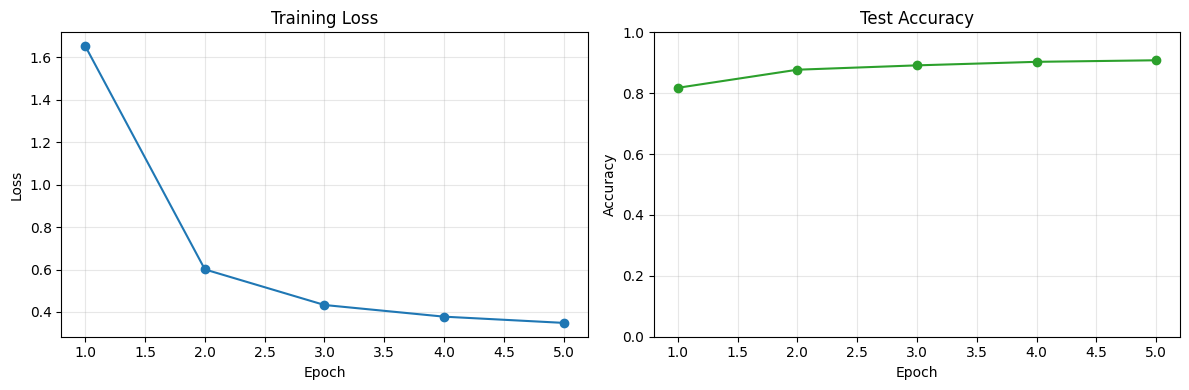

In [21]:
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, marker="o", color="tab:blue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, test_accs, marker="o", color="tab:green")
axes[1].set_title("Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


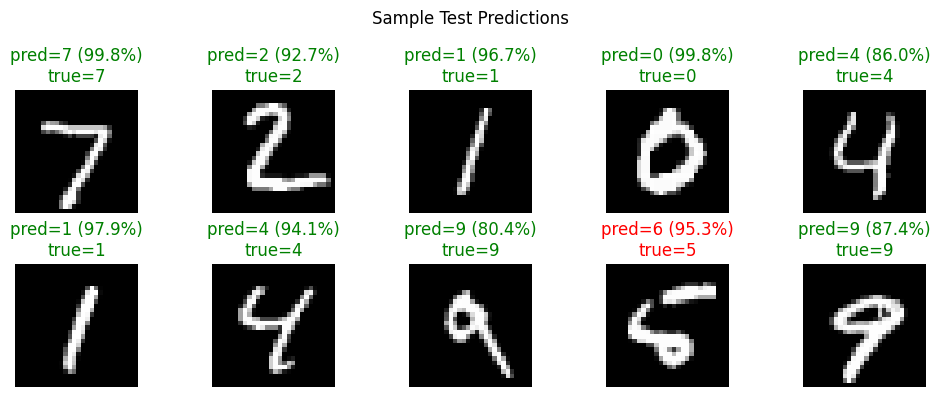

In [22]:
images, labels = next(iter(test_loader))
x = images.view(images.size(0), -1)

with torch.no_grad():
    hidden = F.relu(x @ w1 + b1)
    logits = hidden @ w2 + b2
    probabilities = torch.softmax(logits, dim=1)
    confidences, predictions = probabilities.max(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze() * 0.5 + 0.5, cmap="gray")
    color = "green" if predictions[i] == labels[i] else "red"
    ax.set_title(
        f"pred={predictions[i].item()} ({confidences[i].item():.1%})\ntrue={labels[i].item()}",
        color=color,
    )
    ax.axis("off")

plt.suptitle("Sample Test Predictions")
plt.tight_layout()
plt.show()


In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # reshape this from (batch_size, 1, 28, 28) to (batch_size, 784)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
torch.manual_seed(0)
model = SimpleNN()
optimizer = optim.SGD(
    model.parameters(), 
    lr=0.01
    )
# The optimizer is set up to use stochastic gradient descent (SGD) with a learning rate of 0.01.
loss_fn = nn.CrossEntropyLoss()

train_losses_v2 = []
test_accs_v2 = []

for epoch in range(5):
    model.train()
    running_loss = 0.0
    n_samples = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # totla loss for this batch is loss.item() * batch_size, accumulate it to running_loss
        running_loss += loss.item() * images.size(0)
        # count the number of samples in this batch and accumulate it to n_samples
        # this is important for calculating the average loss at the end of the epoch, as we need to divide the total loss by the total number of samples
        n_samples += images.size(0) 
    
    model.eval()
    correct = 0
    # We use torch.no_grad() to disable gradient calculations during the evaluation phase, 
    # which reduces memory usage and speeds up computations 
    # since we don't need gradients for backpropagation when evaluating the model's performance on the test set.
    # testing does not need to modify gradients, so we can safely disable them to save memory and speed up computations.
    with torch.no_grad():
        for images, labels in test_loader:
            correct += (model(images).argmax(dim=1) == labels).sum().item()

    test_acc = correct / len(test_set)
    train_loss = running_loss / n_samples
    train_losses_v2.append(train_loss)
    test_accs_v2.append(test_acc)
    print(f"epoch {epoch + 1}: loss={train_loss:.4f}, test_acc={test_acc:.3f}")

epoch 1: loss=1.0366, test_acc=0.873
epoch 2: loss=0.4557, test_acc=0.895
epoch 3: loss=0.3800, test_acc=0.903
epoch 4: loss=0.3465, test_acc=0.908
epoch 5: loss=0.3256, test_acc=0.913


## Draw your own digit


In [ ]:
try:
    from ipycanvas import Canvas
    from ipywidgets import Button, HBox, VBox, Output
except ModuleNotFoundError as error:
    raise ModuleNotFoundError("Install drawing widgets first: %pip install ipycanvas ipywidgets") from error

from IPython.display import display, clear_output
from PIL import Image, ImageOps
import numpy as np

DRAW_SIZE = 280
BRUSH_SIZE = 18

draw_canvas = Canvas(width=DRAW_SIZE, height=DRAW_SIZE)
draw_canvas.layout.border = "2px solid #444"
draw_canvas.sync_image_data = True
draw_canvas.fill_style = "black"
draw_canvas.fill_rect(0, 0, DRAW_SIZE, DRAW_SIZE)
draw_canvas.stroke_style = "white"
draw_canvas.line_width = BRUSH_SIZE
draw_canvas.line_cap = "round"
draw_canvas.line_join = "round"

is_drawing = False
last_x = 0
last_y = 0

def start_drawing(x, y):
    global is_drawing, last_x, last_y
    is_drawing = True
    last_x = x
    last_y = y

def draw_line(x, y):
    global last_x, last_y
    if not is_drawing:
        return
    draw_canvas.begin_path()
    draw_canvas.move_to(last_x, last_y)
    draw_canvas.line_to(x, y)
    draw_canvas.stroke()
    last_x = x
    last_y = y

def stop_drawing(x=None, y=None):
    global is_drawing
    is_drawing = False

draw_canvas.on_mouse_down(start_drawing)
draw_canvas.on_mouse_move(draw_line)
draw_canvas.on_mouse_up(stop_drawing)

clear_button = Button(description="Clear")
predict_button = Button(description="Predict", button_style="primary")
draw_output = Output()

def clear_drawing(_=None):
    draw_canvas.fill_style = "black"
    draw_canvas.fill_rect(0, 0, DRAW_SIZE, DRAW_SIZE)
    with draw_output:
        clear_output()

clear_button.on_click(clear_drawing)

display(VBox([draw_canvas, HBox([clear_button, predict_button]), draw_output]))


In [ ]:
def canvas_to_mnist_tensor(canvas):
    image_data = np.asarray(canvas.get_image_data(0, 0, DRAW_SIZE, DRAW_SIZE))
    gray = image_data[..., :3].max(axis=2).astype(np.uint8)
    image = Image.fromarray(gray, mode="L")

    bbox = image.getbbox()
    if bbox is None:
        digit = Image.new("L", (28, 28), 0)
    else:
        digit = image.crop(bbox)
        width, height = digit.size
        side = max(width, height)
        padding = max(8, side // 4)
        square = Image.new("L", (side + 2 * padding, side + 2 * padding), 0)
        square.paste(digit, ((square.width - width) // 2, (square.height - height) // 2))
        digit = square.resize((28, 28), Image.Resampling.LANCZOS)

    array = np.asarray(digit).astype(np.float32) / 255.0
    tensor = torch.tensor(array).unsqueeze(0).unsqueeze(0)
    tensor = (tensor - 0.5) / 0.5
    return tensor, digit

def predict_drawn_digit(_=None):
    tensor, digit = canvas_to_mnist_tensor(draw_canvas)

    with torch.no_grad():
        if "model" in globals() and isinstance(model, nn.Module):
            model.eval()
            logits = model(tensor)
        elif all(name in globals() for name in ["w1", "b1", "w2", "b2"]):
            x = tensor.view(tensor.size(0), -1)
            hidden = F.relu(x @ w1 + b1)
            logits = hidden @ w2 + b2
        else:
            with draw_output:
                clear_output()
                print("Train the model first, then click Predict.")
            return

        probs = torch.softmax(logits, dim=1).squeeze(0)
        prediction = int(probs.argmax().item())
        confidence = float(probs[prediction].item())

    with draw_output:
        clear_output()
        fig, axes = plt.subplots(1, 2, figsize=(8, 3))
        axes[0].imshow(digit, cmap="gray")
        axes[0].set_title(f"Prediction: {prediction} ({confidence:.1%})")
        axes[0].axis("off")

        axes[1].bar(range(10), probs.detach().cpu().numpy(), color="tab:blue")
        axes[1].set_xticks(range(10))
        axes[1].set_ylim(0, 1)
        axes[1].set_xlabel("Digit")
        axes[1].set_ylabel("Probability")
        axes[1].set_title("Probability by Digit")
        axes[1].grid(True, axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()

predict_button.on_click(predict_drawn_digit)
